In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf


In [ ]:
from keras.datasets import cifar10

In [ ]:
((x_train, y_train), (x_test, y_test)) =  cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


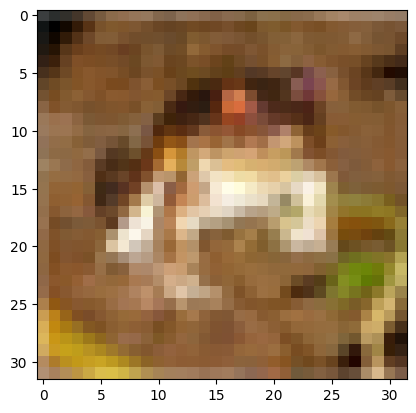

In [ ]:
plt.imshow(x_train[0]);

In [ ]:
y_train[0]

array([6], dtype=uint8)

In [ ]:
CATEGORIES = ['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
CATEGORIES[6]

'frog'

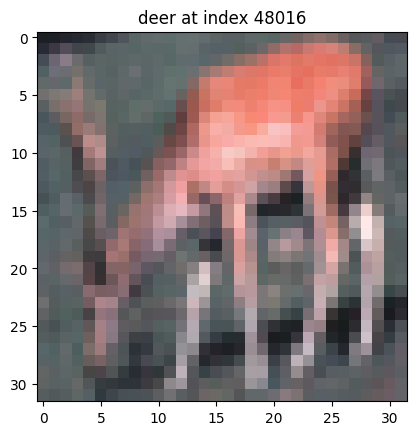

In [ ]:
INDEX = np.random.randint(0, 50000)

plt.imshow(x_train[INDEX]);
plt.title(f"{CATEGORIES[y_train[INDEX][0]] } at index {INDEX}");

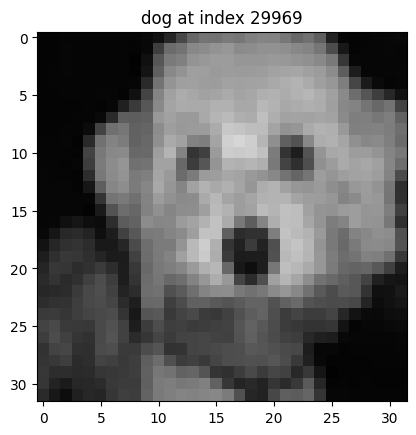

In [ ]:
INDEX = np.random.randint(0, 50000)

plt.imshow(x_train[INDEX]);
plt.title(f"{CATEGORIES[y_train[INDEX][0]] } at index {INDEX}");

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
x_train[0].shape

(32, 32, 3)

In [ ]:
CNN_cifar10 = tf.keras.models.Sequential(
    [
        # Input shape depinde de cum arata imaginea
        tf.keras.layers.Input(shape=(32, 32, 3)),


        # CNN

        ## Rescalez imaginea de la 0..255 la maxim 0..1
        tf.keras.layers.Rescaling(scale=1./255),
        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=32, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=64, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # FULLY CONNECTED

        # Architectura de fully connected
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),

        tf.keras.layers.Dropout(0.2), # Random -20% dintre neuroni sunt dezactivati

        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')


    ]
)

CNN_cifar10.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
CNN_cifar10.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,338 (1.23 MB)

 Trainable params: 323,338 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

# Pas 1 - adaugarea mai multor imagini

In [ ]:
#

augumentation_layer = tf.keras.Sequential([
    ## Data Augumentation - flip, rotate, zoom, contrast
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),


])


In [ ]:
augumented_CNN_cifar10 = tf.keras.models.Sequential(
    [
        # Input shape depinde de cum arata imaginea
        tf.keras.layers.Input(shape=(32, 32, 3)),



        # Augumentation layer - operatii random in memorie de procesare a imaginilor
        augumentation_layer,


        # CNN

        ## Rescalez imaginea de la 0..255 la maxim 0..1
        tf.keras.layers.Rescaling(scale=1./255),
        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=32, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=64, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # FULLY CONNECTED

        # Architectura de fully connected
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),

        tf.keras.layers.Dropout(0.2), # Random -20% dintre neuroni sunt dezactivati

        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')


    ]
)

augumented_CNN_cifar10.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
augumented_CNN_cifar10.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,338 (1.23 MB)

 Trainable params: 323,338 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
augumentation_layer.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 15

without_augmentation_history = CNN_cifar10.fit(x_train, y_train, validation_split=0.2, epochs=EPOCHS, verbose=0)
augmentation_history  = augumented_CNN_cifar10.fit(x_train, y_train, validation_split=0.2, epochs=EPOCHS, verbose=0)

In [31]:
without_augmentation_history.history

{'accuracy': [0.41929998993873596,
  0.5633249878883362,
  0.6208249926567078,
  0.6551499962806702,
  0.6855999827384949,
  0.7070749998092651,
  0.7262750267982483,
  0.7444499731063843,
  0.7620000243186951,
  0.7756999731063843,
  0.7878999710083008,
  0.7983750104904175,
  0.8138750195503235,
  0.8181250095367432,
  0.828249990940094],
 'loss': [1.5828651189804077,
  1.224851131439209,
  1.076297402381897,
  0.9765967726707458,
  0.8981972932815552,
  0.8301835656166077,
  0.7701752781867981,
  0.7196122407913208,
  0.6719040870666504,
  0.6238273978233337,
  0.594825267791748,
  0.5642269253730774,
  0.5267373919487,
  0.5059897899627686,
  0.47689950466156006],
 'val_accuracy': [0.5386000275611877,
  0.6074000000953674,
  0.6449999809265137,
  0.6539000272750854,
  0.6762999892234802,
  0.6870999932289124,
  0.6818000078201294,
  0.694100022315979,
  0.6876000165939331,
  0.6818000078201294,
  0.6851999759674072,
  0.6923999786376953,
  0.6859999895095825,
  0.692300021648407,
 

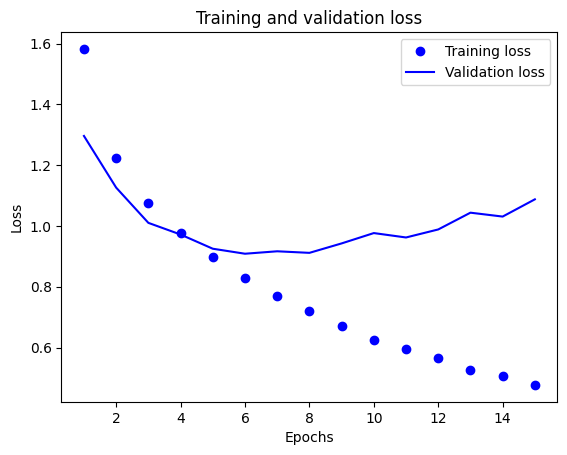

In [33]:
history_dict = without_augmentation_history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.legend()
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

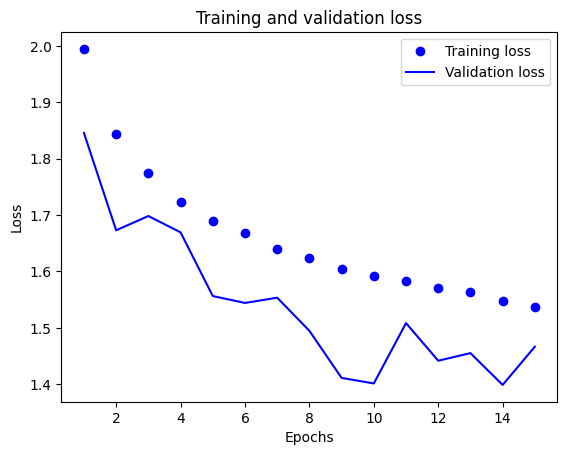

In [34]:
history_dict = augmentation_history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.legend()
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Pas 2 -> adaugarea mai multor epoci, dar care sa se opreasca daca validarea nu scade continuu

In [36]:
augumentation_layer = tf.keras.Sequential([
    ## Data Augumentation - flip, rotate, zoom, contrast
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),

])

early_stop_augumented_CNN_cifar10 = tf.keras.models.Sequential(
    [
        # Input shape depinde de cum arata imaginea
        tf.keras.layers.Input(shape=(32, 32, 3)),



        # Augumentation layer - operatii random in memorie de procesare a imaginilor
        augumentation_layer,


        # CNN

        ## Rescalez imaginea de la 0..255 la maxim 0..1
        tf.keras.layers.Rescaling(scale=1./255),
        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=32, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=64, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # FULLY CONNECTED

        # Architectura de fully connected
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),

        tf.keras.layers.Dropout(0.2), # Random -20% dintre neuroni sunt dezactivati

        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')


    ]
)

early_stop_augumented_CNN_cifar10.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [37]:
EPOCHS = 70 # un numar mare, se va opri mai devreme
# patience=5 -> 5 epoci consecutive in care nu exista o imbunatatire
stop_callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

early_stop_augumented_CNN_cifar10.fit(x_train, y_train, epochs=EPOCHS,  validation_split=0.2, callbacks=[stop_callback])

Epoch 1/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.2263 - loss: 2.0552 - val_accuracy: 0.3477 - val_loss: 1.8133
Epoch 2/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.3177 - loss: 1.8451 - val_accuracy: 0.4159 - val_loss: 1.6040
Epoch 3/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.3558 - loss: 1.7616 - val_accuracy: 0.4077 - val_loss: 1.6395
Epoch 4/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.3761 - loss: 1.7192 - val_accuracy: 0.4205 - val_loss: 1.5930
Epoch 5/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.3916 - loss: 1.6748 - val_accuracy: 0.4642 - val_loss: 1.4902
Epoch 6/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.4022 - loss: 1.6495 - val_accuracy: 0.4628 - val_loss: 1.4914
Epoch 7/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.4081 - loss: 1.6344 - val_accuracy: 0.4436 - val_loss: 1.5783
Epoch 8/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.4113 -

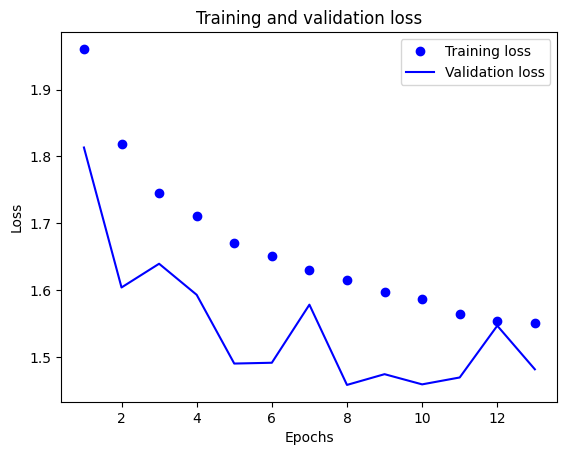

In [39]:
history_dict = early_stop_augumented_CNN_cifar10.history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.legend()
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Pas 3 - imbunatatirea arhitecturii modelului
1. Convolutia + MaxPooling de mai multe ori
2. Mai multe layer de neuroni
3. Mai multe operatii de augumentare

In [42]:
augumentation_layer = tf.keras.Sequential([
    ## Data Augumentation - flip, rotate, zoom, contrast
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
    ## Adaugarea altor elemente
    tf.keras.layers.RandomContrast(0.2),

])

multiple_ops_early_stop_augumented_CNN_cifar10 = tf.keras.models.Sequential(
    [
        # Input shape depinde de cum arata imaginea
        tf.keras.layers.Input(shape=(32, 32, 3)),



        # Augumentation layer - operatii random in memorie de procesare a imaginilor
        augumentation_layer,


        # CNN

        ## Rescalez imaginea de la 0..255 la maxim 0..1
        tf.keras.layers.Rescaling(scale=1./255),
        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=32, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=64, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=128, activation="relu"),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # FULLY CONNECTED

        # Architectura de fully connected
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2), # Random -20% dintre neuroni sunt dezactivati


        tf.keras.layers.Dense(128, activation='relu'),

        tf.keras.layers.Dropout(0.2), # Random -20% dintre neuroni sunt dezactivati

        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')


    ]
)

multiple_ops_early_stop_augumented_CNN_cifar10.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [43]:
EPOCHS = 70 # un numar mare, se va opri mai devreme
# patience=5 -> 5 epoci consecutive in care nu exista o imbunatatire
stop_callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

multiple_ops_early_stop_augumented_CNN_cifar10.fit(x_train, y_train, epochs=EPOCHS,  validation_split=0.2, callbacks=[stop_callback])

Epoch 1/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.1893 - loss: 2.1199 - val_accuracy: 0.2968 - val_loss: 1.8172
Epoch 2/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.2776 - loss: 1.9094 - val_accuracy: 0.3355 - val_loss: 1.7959
Epoch 3/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.3375 - loss: 1.8052 - val_accuracy: 0.4289 - val_loss: 1.5718
Epoch 4/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.3652 - loss: 1.7362 - val_accuracy: 0.4269 - val_loss: 1.5542
Epoch 5/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.3845 - loss: 1.6875 - val_accuracy: 0.4637 - val_loss: 1.4748
Epoch 6/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.4014 - loss: 1.6543 - val_accuracy: 0.4318 - val_loss: 1.5375
Epoch 7/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - accuracy: 0.4141 - loss: 1.6181 - val_accuracy: 0.4537 - val_loss: 1.4931
Epoch 8/70
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 38ms/step - accuracy: 0.4172 -